In [1]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Copy the zip file from My Drive to the local Colab storage
!cp "/content/drive/MyDrive/anime_faces.zip" "/content/anime_faces.zip"

# 3. Unzip the dataset into a new folder
!unzip -q "/content/anime_faces.zip" -d "/content/"

print("Dataset copied and unzipped successfully!")

Mounted at /content/drive
Dataset copied and unzipped successfully!


In [2]:
# installation cell
!pip install piq kornia onnx onnxscript lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.0 MB/s eta 0:00:00


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from piq import ssim as ssim_func
import os
import shutil
from tqdm import tqdm
from torch.utils.data import TensorDataset
import kornia
from torch.nn.utils import spectral_norm
import lpips

In [4]:
# HYPERPARAMETERS
total_epochs = 20
warmup_epochs = 5
warmup_start = 5
beta_initial = 1e-3
beta_target = 1e-2
latent_dim = 16
learning_rate_G = 5e-5
learning_rate_D = 2.5e-5
adv_weight = 0.2
adv_start = 10
batch_size = 64
patience = 40
scheduler_factor = 0.75

In [5]:
# 1. Basic transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

# 2. Point to your image folder
dataset = datasets.ImageFolder(root='./anime_faces/train', transform=transform)
val_dataset = datasets.ImageFolder(root='./anime_faces/val',transform=transform)

# 3. Create the DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset,batch_size=batch_size,num_workers=os.cpu_count())

# 4. Test it: Pull one batch of images
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([64, 3, 64, 64])


In [6]:
class ResDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResDownBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            # Downsample
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8,out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            # Refine
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8,out_channels)
        )

        # Skip path
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2),
            nn.GroupNorm(8,out_channels)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(self.main(x) + self.shortcut(x))

class ResUpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResUpBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            # Upsample
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8,out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            # Refine
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8,out_channels)
        )

        # Skip Path
        self.shortcut = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.GroupNorm(8,out_channels)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        # Element-wise addition
        return self.act(self.main(x) + self.shortcut(x))



class DiscResDownBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(DiscResDownBlock, self).__init__()

    # main path
    self.main = nn.Sequential(
        spectral_norm(nn.Conv2d(in_channels,out_channels,kernel_size=4,stride=2,padding=1)),
        nn.LeakyReLU(negative_slope=0.2,inplace=True),
        spectral_norm(nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1)),
    )

    # skip path
    self.shortcut = nn.Sequential(
        spectral_norm(nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=2)),
    )

    self.act = nn.LeakyReLU(negative_slope=0.2,inplace=True)

  def forward(self,x):
    return self.act(self.main(x)+self.shortcut(x))




class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        # Query, Key, Value projections (1x1 convs)
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        # Learnable scale (starts at 0, grows during training)
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        # Project and reshape to (B, C//8, N)
        q = self.query(x).view(B, -1, N).permute(0, 2, 1)  # (B, N, C//8)
        k = self.key(x).view(B, -1, N)                      # (B, C//8, N)
        v = self.value(x).view(B, -1, N)                    # (B, C, N)

        # Attention map: (B, N, N)
        attn = self.softmax(torch.bmm(q, k))

        # Attended output: (B, C, H, W)
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)

        return self.gamma * out + x  # Residual connection

In [7]:

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator,self).__init__()

        self.net = nn.Sequential(
            # 3x64x64 to 32x32x32
            DiscResDownBlock(3,32),

            # 32x32x32 to 64x16x16
            DiscResDownBlock(32,64),

            # 64x16x16 to 128x8x8
            DiscResDownBlock(64,128),

            # 128x8x8 to 256x4x4
            DiscResDownBlock(128,256),

            # self spatial attention layer
            SpatialAttention(256),

            nn.Flatten(),

            spectral_norm(nn.Linear(256*4*4,128)),
            nn.ReLU(),
            spectral_norm(nn.Linear(128,1)),
        )

    def forward(self,x):
        return self.net(x)

In [8]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()

        # Encoder: 3x64x64 -> Latent Space
        self.encoder = nn.Sequential(

            # 3x64x64 to 32x32x32
            ResDownBlock(3,32),

            # 32x32x32 to 64x16x16
            ResDownBlock(32,64),

            # 64x16x16 to 128x8x8
            ResDownBlock(64,128),

            # 128x8x8 to 256x4x4
            ResDownBlock(128,256),

            # self spatial attention layer
            SpatialAttention(256),

            nn.Flatten()
        )

        # Latent vectors (mu and log_var)
        # 256 * 4 * 4 = 4096
        self.fc_mu = nn.Linear(4096,latent_dim)
        self.fc_logvar = nn.Linear(4096,latent_dim)

        # Decoder: Latent Space -> 3x48x48
        self.decoder_input = nn.Linear(latent_dim, 4096)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),

            # self spatial attention layer
            SpatialAttention(256),

            # 256x4x4 to 128x8x8
            ResUpBlock(256,128),

            # 128x8x8 to 64x16x16
            ResUpBlock(128,64),

            # 64x16x16 to 32x32x32
            ResUpBlock(64,32),

            # 32x32x32 to 3x64x64 (Final layer no skip connection needed)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners = False), # 64x64
            # Upsample
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.2,inplace=True),
            # Refine
            nn.Conv2d(32,3,kernel_size=3,padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """The Reparameterization Trick: z = mu + std * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar



In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
model = BetaVAE(latent_dim=latent_dim).to(device)
discriminator = Discriminator().to(device)

cuda


In [10]:
lpips_fn = lpips.LPIPS(net='vgg').to(device).eval()

# --- The Beta-VAE Loss Function ---
def loss_function(recon_x, x, mu, logvar, beta=4.0,z=1,free_bits=0.15):

    recon_lpips = recon_x * 2 - 1
    real_lpips  = x * 2 - 1
    lpips_loss = lpips_fn(recon_lpips, real_lpips).mean()

    # L1 loss
    l1_loss = F.l1_loss(recon_x, x, reduction='mean')

    # Reconstruction Loss lpips + z*L1
    reconstruction_loss = lpips_loss + z * l1_loss

    # 2. KL Divergence
    kld_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    # Instead of clamping to a minimum value, subtract the free_bits budget, and don't let it drop below 0.0
    kld_loss_per_dim = torch.max(kld_per_dim - free_bits, torch.zeros_like(kld_per_dim))

    # Now sum across dimensions and average over the batch
    kld_loss = torch.sum(kld_loss_per_dim, dim=1).mean()

    # Total loss
    total_loss = reconstruction_loss + (beta * kld_loss)
    return total_loss, reconstruction_loss, kld_loss

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.3MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


In [11]:
optimizer_G = torch.optim.Adam(model.parameters(), lr=learning_rate_G, betas=(0.5,0.9))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=learning_rate_D, betas=(0.5,0.9))

scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode='min', factor=scheduler_factor, patience=patience
)

In [12]:
def train_epoch(model, discriminator, dataloader, optimizer_G, optimizer_D, device, beta_weight=4.0, curr_adv_weight=0.1):
    model.train()
    discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    # Track sum of KLD for each of the 16 dimensions
    running_kld_per_dim = torch.zeros(16).to(device)

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", leave=False)

    for images, _ in progress_bar:
        images = images.to(device)
        batch_size = images.size(0)

        # ================================FORWARD PASS (SINGLE)================================
        recon_batch, mu, logvar = model(images)

        # Calculate raw un-clamped KLD per dimension: (batch_size, 16)
        kld_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        # Detach here to free the computational graph and prevent memory leaks
        running_kld_per_dim += kld_per_dim.detach().sum(dim=0)


        # ================================Train Discriminator================================
        d_loss = torch.tensor(0.0)
        if curr_adv_weight > 0:
            optimizer_D.zero_grad()
            real_preds = discriminator(images)
            d_loss_real = torch.mean((real_preds - 1) ** 2)
            fake_preds = discriminator(recon_batch.detach())
            d_loss_fake = torch.mean(fake_preds ** 2)
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            optimizer_D.step()

        # ================================Train Generator====================================
        optimizer_G.zero_grad()
        vae_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        if curr_adv_weight > 0:
            fake_preds_for_G = discriminator(recon_batch)
            g_adv_loss = torch.mean((fake_preds_for_G - 1) ** 2)
        else:
            g_adv_loss = 0.0

        g_loss = vae_loss + curr_adv_weight * g_adv_loss
        g_loss.backward()
        optimizer_G.step()

        running_g_loss += g_loss.item() * batch_size
        running_d_loss += d_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

        progress_bar.set_postfix({
            "G_Loss": f"{g_loss.item():.3f}",
            "D_Loss": f"{d_loss.item():.3f}",
            "Rec": f"{batch_rec.item():.3f}"
        })

    dataset_size = len(dataloader.dataset)

    # Compute epoch average for all 16 dimensions
    epoch_kld_per_dim = (running_kld_per_dim / dataset_size).cpu().numpy()

    return running_g_loss/dataset_size, running_d_loss/dataset_size, running_rec/dataset_size, running_kld/dataset_size, epoch_kld_per_dim


In [13]:
# --- Validation Function ---
@torch.no_grad()
def validate_epoch(model, discriminator, dataloader, device, beta_weight=4.0,curr_adv_weight=0.1):
    """Runs a single pass over the validation set without tracking gradients."""
    model.eval()
    discriminator.eval()

    running_g_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)
        real_labels = torch.ones(batch_size,1).to(device)

        # Forward pass only
        recon_batch, mu, logvar = model(images)
        vae_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # calc how well G fooled D
        fake_preds_for_G = discriminator(recon_batch)
        g_adv_loss = torch.mean((fake_preds_for_G - 1) ** 2)

        g_loss = vae_loss + curr_adv_weight*g_adv_loss

        # Accumulate sums
        running_g_loss += g_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

    dataset_size = len(dataloader.dataset)
    return running_g_loss / dataset_size, running_rec / dataset_size, running_kld / dataset_size

In [14]:
def save_checkpoint(state_dict, is_best, folder="./checkpoints", filename="checkpoint.pth"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    # Save the latest epoch
    torch.save(state_dict, filepath)

    # If it's the best so far, overwrite the best model file
    if is_best:
        best_filepath = os.path.join(folder, "model_best.pth")
        shutil.copyfile(filepath, best_filepath)
        # Updated key here to match the new payload!
        print(f"--> ✨ New best model saved! Val Loss: {state_dict['best_val_loss']:.4f}")

In [15]:
# checkpoint_path = "/content/drive/MyDrive/checkpointv4.pth"
# checkpoint_path = "./checkpoints/checkpoint.pth"
checkpoint_path = ""

# --- Setup & Nomenclature ---
best_val_loss = float('inf')

start_epoch = 1

# Clean history tracking, now actually tracking validation
history = {
    'train_g_loss': [], 'train_d_loss': [], 'train_rec': [], 'train_kld': [],
    'val_g_loss': [], 'val_rec': [], 'val_kld': [],
    'learning_rate': []
}

# Check if the file actually exists
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Loading...")

    # Load the model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restore the model and optimizer memory
    model.load_state_dict(checkpoint['model_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])

    # Restore our trackers
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    history = checkpoint['history']

    print(f"Resuming training from Epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch.")

No checkpoint found. Starting training from scratch.


In [16]:
def cache_dataset_vram(dataset, device):
    """Load all images directly into VRAM (GPU memory) as a single tensor batch."""

    # pin_memory=True speeds up the initial transfer from CPU to GPU
    loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=True)
    images_list, labels_list = [], []

    for imgs, lbls in tqdm(loader, desc=f"Caching to VRAM ({device})"):
        # Move data to the GPU immediately
        # non_blocking=True allows asynchronous data transfers, speeding up the process
        images_list.append(imgs.to(device, non_blocking=True))
        labels_list.append(lbls.to(device, non_blocking=True))

    return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# --- How to use it ---
# # Make sure 'device' is defined before calling this!
print("Caching train set to VRAM...")
train_cached_vram = cache_dataset_vram(dataset, device)
print("Caching val set to VRAM...")
val_cached_vram   = cache_dataset_vram(val_dataset, device)

# # Replace the loaders with VRAM-based loaders
# # IMPORTANT: num_workers MUST be 0 here because multiprocessing cannot handle GPU tensors
train_loader = DataLoader(train_cached_vram, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_cached_vram,   batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Done. Train: {len(train_cached_vram)} | Val: {len(val_cached_vram)}")

Caching train set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 245/245 [00:36<00:00,  6.77it/s]


Caching val set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 4/4 [00:00<00:00,  6.64it/s]

Done. Train: 62541 | Val: 1024


In [17]:
print(f"Starting training on device: {device}")

for epoch in range(start_epoch, total_epochs + 1):
    # Step function for Beta Warmup
    current_beta = beta_initial if epoch < warmup_start else min(beta_target, beta_initial + beta_target * (epoch - warmup_start) / warmup_epochs)
    current_lr = optimizer_G.param_groups[0]['lr']
    curr_adv_weight = 0 if epoch < adv_start else adv_weight

    print(f"Epoch [{epoch}/{total_epochs}] | Beta: {current_beta:.4f} | LR: {current_lr}")

    # 1. Run one training epoch
    train_g, train_d, train_rec, train_kld, train_kld_per_dim = train_epoch(
        model,
        discriminator,
        train_loader,
        optimizer_G,
        optimizer_D,
        device,
        current_beta,
        curr_adv_weight
    )

    # 2. Run one validation epoch
    val_g, val_rec, val_kld = validate_epoch(
        model,
        discriminator,
        val_loader,
        device,
        current_beta,
        curr_adv_weight
    )

    # 3. Record history
    history['train_g_loss'].append(train_g)
    history['train_d_loss'].append(train_d)
    history['train_rec'].append(train_rec)
    history['train_kld'].append(train_kld)

    history['val_g_loss'].append(val_g)
    history['val_rec'].append(val_rec)
    history['val_kld'].append(val_kld)
    history['learning_rate'].append(current_lr)

    # 4. Print logs
    print(f"  Train -> G-Loss: {train_g:.4f} | D-Loss: {train_d:.4f} (Rec: {train_rec:.4f}, KLD: {train_kld:.4f})")

    # Print 16D array values with 3 decimal precision
    kld_str = ", ".join([f"{val:.3f}" for val in train_kld_per_dim])
    print(f"  Train KLD per dim: [{kld_str}]")

    print(f"  Val   -> G-Loss: {val_g:.4f} (Rec: {val_rec:.4f}, KLD: {val_kld:.4f})")


    # 5. Check if this is the best model (Evaluating based on VALIDATION loss)
    is_best = val_rec < best_val_loss
    if is_best:
        best_val_loss = val_rec

# 6. Save Checkpoint payload with the new Discriminator variables
    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'scheduler_G_state_dict': scheduler_G.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }
    save_checkpoint(checkpoint_payload, is_best)

    scheduler_G.step(val_rec)

Starting training on device: cuda
Epoch [1/20] | Beta: 0.0010 | LR: 5e-05


  Train -> G-Loss: 0.5728 | D-Loss: 0.0000 (Rec: 0.5520, KLD: 20.8478)
  Train KLD per dim: [1.311, 1.055, 1.321, 1.372, 2.383, 1.256, 1.049, 1.632, 1.736, 2.142, 1.013, 1.558, 1.232, 1.340, 1.850, 0.993]
  Val   -> G-Loss: 0.5275 (Rec: 0.5064, KLD: 21.0643)
--> ✨ New best model saved! Val Loss: 0.5064
Epoch [2/20] | Beta: 0.0010 | LR: 5e-05


  Train -> G-Loss: 0.5015 | D-Loss: 0.0000 (Rec: 0.4793, KLD: 22.1735)
  Train KLD per dim: [1.566, 1.205, 1.501, 1.577, 2.001, 1.480, 1.209, 1.555, 1.972, 1.831, 1.096, 1.814, 1.293, 1.587, 1.719, 1.166]
  Val   -> G-Loss: 0.5066 (Rec: 0.4845, KLD: 22.0639)
--> ✨ New best model saved! Val Loss: 0.4845
Epoch [3/20] | Beta: 0.0010 | LR: 5e-05


  Train -> G-Loss: 0.4830 | D-Loss: 0.0000 (Rec: 0.4608, KLD: 22.1749)
  Train KLD per dim: [1.613, 1.212, 1.503, 1.620, 1.859, 1.510, 1.251, 1.530, 2.038, 1.725, 1.097, 1.865, 1.292, 1.632, 1.668, 1.159]
  Val   -> G-Loss: 0.4932 (Rec: 0.4710, KLD: 22.2332)
--> ✨ New best model saved! Val Loss: 0.4710
Epoch [4/20] | Beta: 0.0010 | LR: 5e-05


  Train -> G-Loss: 0.4731 | D-Loss: 0.0000 (Rec: 0.4509, KLD: 22.2067)
  Train KLD per dim: [1.646, 1.214, 1.507, 1.615, 1.799, 1.523, 1.266, 1.537, 2.109, 1.670, 1.072, 1.902, 1.281, 1.677, 1.649, 1.140]
  Val   -> G-Loss: 0.4806 (Rec: 0.4588, KLD: 21.8311)
--> ✨ New best model saved! Val Loss: 0.4588
Epoch [5/20] | Beta: 0.0010 | LR: 5e-05


...

  Train -> G-Loss: 0.6678 | D-Loss: 0.2032 (Rec: 0.5556, KLD: 3.7611)
  Train KLD per dim: [0.623, 0.185, 0.371, 0.254, 0.223, 0.477, 0.198, 0.213, 1.119, 0.215, 0.172, 0.693, 0.194, 0.634, 0.184, 0.190]
  Val   -> G-Loss: 0.6534 (Rec: 0.5664, KLD: 3.8087)
Epoch [17/20] | Beta: 0.0100 | LR: 5e-05


  Train -> G-Loss: 0.6690 | D-Loss: 0.2029 (Rec: 0.5557, KLD: 3.8085)
  Train KLD per dim: [0.630, 0.186, 0.373, 0.263, 0.229, 0.479, 0.205, 0.215, 1.128, 0.235, 0.174, 0.689, 0.193, 0.622, 0.184, 0.192]
  Val   -> G-Loss: 0.6764 (Rec: 0.5589, KLD: 4.1306)
Epoch [18/20] | Beta: 0.0100 | LR: 5e-05


  Train -> G-Loss: 0.6686 | D-Loss: 0.2044 (Rec: 0.5561, KLD: 3.7902)
  Train KLD per dim: [0.642, 0.185, 0.360, 0.254, 0.217, 0.487, 0.207, 0.208, 1.119, 0.234, 0.178, 0.689, 0.192, 0.628, 0.187, 0.195]
  Val   -> G-Loss: 0.6445 (Rec: 0.5699, KLD: 3.9860)
Epoch [19/20] | Beta: 0.0100 | LR: 5e-05


  Train -> G-Loss: 0.6697 | D-Loss: 0.2054 (Rec: 0.5570, KLD: 3.7842)
  Train KLD per dim: [0.626, 0.186, 0.354, 0.254, 0.213, 0.482, 0.208, 0.210, 1.126, 0.239, 0.177, 0.699, 0.193, 0.623, 0.182, 0.199]
  Val   -> G-Loss: 0.6756 (Rec: 0.5654, KLD: 3.7060)
Epoch [20/20] | Beta: 0.0100 | LR: 5e-05


  Train -> G-Loss: 0.6693 | D-Loss: 0.2041 (Rec: 0.5561, KLD: 3.8273)
  Train KLD per dim: [0.638, 0.190, 0.378, 0.248, 0.205, 0.473, 0.208, 0.222, 1.130, 0.240, 0.186, 0.695, 0.195, 0.612, 0.186, 0.210]
  Val   -> G-Loss: 0.6500 (Rec: 0.5609, KLD: 4.0960)


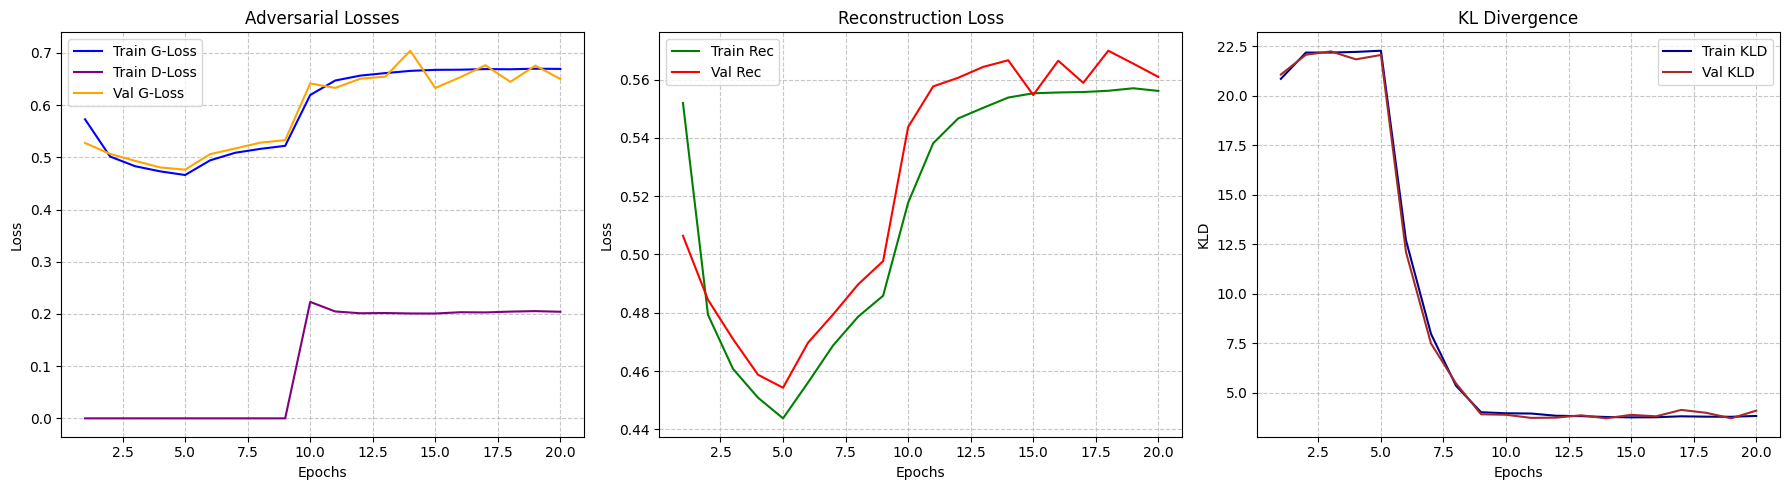

In [18]:
def plot_training_curves(history):
    # Determine the number of epochs trained so far
    epochs = range(1, len(history['train_g_loss']) + 1)

    # Create a 1x3 grid for our plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. GAN Losses (Generator vs Discriminator) ---
    axes[0].plot(epochs, history['train_g_loss'], label='Train G-Loss', color='blue')
    axes[0].plot(epochs, history['train_d_loss'], label='Train D-Loss', color='purple')
    axes[0].plot(epochs, history['val_g_loss'], label='Val G-Loss', color='orange')
    axes[0].set_title('Adversarial Losses')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- 2. Reconstruction Loss ---
    axes[1].plot(epochs, history['train_rec'], label='Train Rec', color='green')
    axes[1].plot(epochs, history['val_rec'], label='Val Rec', color='red')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- 3. KL Divergence ---
    axes[2].plot(epochs, history['train_kld'], label='Train KLD', color='darkblue')
    axes[2].plot(epochs, history['val_kld'], label='Val KLD', color='brown')
    axes[2].set_title('KL Divergence')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('KLD')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function to display the plots
plot_training_curves(history)

In [19]:
model.load_state_dict(torch.load('./checkpoints/checkpoint.pth', map_location=device)['model_state_dict'])
model.eval()

BetaVAE(
  (encoder): Sequential(
    (0): ResDownBlock(
      (main): Sequential(
        (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      )
      (act): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): ResDownBlock(
      (main): Sequential(
        (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True

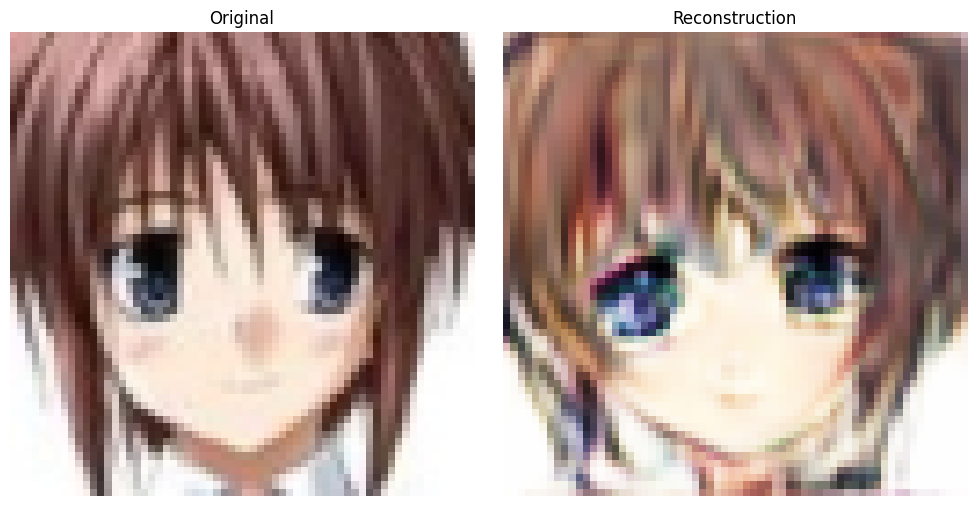

In [20]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_single_image(image_path, model):
    # 1. Ensure image is loaded as RGB (3 channels)
    img = Image.open(image_path).convert('RGB')

    # 2. Use 'transform' (the variable you defined in Cell 3), NOT 'transforms' (the module)
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        # Get the reconstruction from the VAE
        reconstruction, mu, logvar = model(img_tensor)

    return img_tensor, reconstruction

def show_results(original, reconstructed):
    # 1. Squeeze to remove batch dim, move to CPU
    # 2. Permute from (C, H, W) to (H, W, C) so Matplotlib can read it
    orig_np = original.squeeze().permute(1, 2, 0).cpu().numpy()
    recon_np = reconstructed.squeeze().permute(1, 2, 0).cpu().numpy()

    # 3. Clip values to [0, 1] to prevent artifacting in visualization
    orig_np = orig_np.clip(0, 1)
    recon_np = recon_np.clip(0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot Original
    axes[0].imshow(orig_np)
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Plot Reconstruction
    axes[1].imshow(recon_np)
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the test
orig, recon = predict_single_image('./anime_faces/val/all/13631_2006.jpg', model)
show_results(orig, recon)

In [21]:
import onnx

# 1. Wrapper module to return mu (the deterministic latent mapping)
class EncoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.encoder = full_model.encoder
        self.fc_mu = full_model.fc_mu

    def forward(self, x):
        h = self.encoder(x)
        return self.fc_mu(h)

# 2. Instantiate and prepare
encoder_model = EncoderOnly(model).to(device)
encoder_model.eval()

# 3. Create dummy input shape [1, 3, 64, 64]
dummy_img = torch.randn(1, 3, 64, 64).to(device)

# 4. Export to ONNX
torch.onnx.export(
    encoder_model,
    dummy_img,
    "encoderv4.onnx",
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['input_image'],
    output_names=['latent_z']
)


W0522 13:12:23.732000 1781 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0522 13:12:24.700000 1781 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0522 13:12:24.702000 1781 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio

[torch.onnx] Obtain model graph for `EncoderOnly([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EncoderOnly([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_image"<FLOAT,[1,3,64,64]>
            ),
            outputs=(
                %"latent_z"<FLOAT,[1,16]>
            ),
            initializers=(
                %"encoder.0.main.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"encoder.0.main.3.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"encoder.0.shortcut.0.weight"<FLOAT,[32,3,1,1]>{TorchTensor(...)},
                %"encoder.0.shortcut.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"encoder.1.main.0.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"encoder.1.main.3.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"encoder.1.shortcut.0.bias"<FLOAT,[64]>{TorchTensor(.

In [22]:
import onnx

# 1. Match the latent_dim from your hyperparameters
latent_input = torch.randn(1, latent_dim).to(device)

# 2. Simplified Wrapper
class DecoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        # Keep these as references to the original model layers
        self.decoder_input = full_model.decoder_input
        self.decoder = full_model.decoder

    def forward(self, z):
        # Apply the linear projection
        x = self.decoder_input(z)
        # The first layer of self.decoder is Unflatten,
        # so it handles the (256, 3, 3) conversion for us.
        return self.decoder(x)

# 3. Prepare model for export
decoder_model = DecoderOnly(model).to(device)
decoder_model.eval()

# 4. Export to ONNX
torch.onnx.export(
    decoder_model,
    latent_input,
    "decoder.onnx",
    export_params=True,        # Store trained weights inside the file
    opset_version=12,          # Standard version for web/frontend compatibility
    do_constant_folding=True,  # Optimization
    input_names=['latent_z'],  # Friendly name for your frontend sliders
    output_names=['reconstruction']
)

# 5. Optional: Verify and save
onnx_model = onnx.load("decoder.onnx")
onnx.checker.check_model(onnx_model)
onnx.save(onnx_model, "decoder.onnx")

print("ONNX export complete: decoder.onnx")

W0522 13:12:27.502000 1781 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0522 13:12:28.220000 1781 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0522 13:12:28.222000 1781 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio

[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export complete: decoder.onnx


In [23]:
!mv ./checkpoints/checkpoint.pth ./drive/MyDrive/checkpointv4.1.pth